In [27]:
import os
import sys
import torch
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

# Add project root to path
project_root = os.path.abspath('..') 
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from networks.PeakDetectionModel import PeakDetectionModel
from run import prepare_dataset

# -------------------- HARD-CODED PARAMETERS --------------------
signal_path = "../data/signal.raw"
info_path = "../data/info.raw"
chunks = 1024
max_peaks = 3
batch_size = 32
shuffle = True
train_split = 0.75
val_split = 0.15
seed = 42  

threshold = 0.009

# -------------------- CONFIGURATION --------------------
model_path = "../networks/final_model.pt"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Create a config object with all needed attributes
class Config:
    signal_path = signal_path
    info_path = info_path
    chunks = chunks
    max_peaks = max_peaks
    batch_size = batch_size
    shuffle = shuffle
    train_split = train_split
    val_split = val_split
    seed = seed 
    device = device

args = Config()
print(f"\nRunning inference on device: {device}")
print(f"Loading model from: {model_path}")




Running inference on device: cuda
Loading model from: ../networks/final_model.pt


In [28]:
# -------------------- DATASET --------------------
_, _, test_loader = prepare_dataset(args)

# -------------------- MODEL --------------------
model = PeakDetectionModel(signal_length=chunks, max_peaks=max_peaks)
print(model.encoder[0].name)  # "entry_layer"
print(model.fc_positions.name)  # "final_layer_positions"
print(model.fc_heights.name)  # "final_layer_heights"
print(model.fc_widths.name)  # "final_layer_widths"

model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

[INFO] Dataset loaded with 50000 signals
[INFO] Train set: 37500 | Val set: 7500 | Test set: 5000
entry_layer
final_layer_positions
final_layer_heights
final_layer_widths


PeakDetectionModel(
  (encoder): Sequential(
    (0): Conv1d(1, 32, kernel_size=(13,), stride=(1,))
    (1): ReLU()
    (2): Conv1d(32, 64, kernel_size=(13,), stride=(1,))
    (3): ReLU()
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
  )
  (fc): Sequential(
    (0): Linear(in_features=32000, out_features=2048, bias=True)
    (1): ReLU()
  )
  (fc_positions): Linear(in_features=2048, out_features=1024, bias=True)
  (fc_heights): Linear(in_features=2048, out_features=3, bias=True)
  (fc_widths): Linear(in_features=2048, out_features=3, bias=True)
)

In [29]:
model

PeakDetectionModel(
  (encoder): Sequential(
    (0): Conv1d(1, 32, kernel_size=(13,), stride=(1,))
    (1): ReLU()
    (2): Conv1d(32, 64, kernel_size=(13,), stride=(1,))
    (3): ReLU()
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
  )
  (fc): Sequential(
    (0): Linear(in_features=32000, out_features=2048, bias=True)
    (1): ReLU()
  )
  (fc_positions): Linear(in_features=2048, out_features=1024, bias=True)
  (fc_heights): Linear(in_features=2048, out_features=3, bias=True)
  (fc_widths): Linear(in_features=2048, out_features=3, bias=True)
)

In [30]:
# -------------------- INFERENCE ON FIRST BATCH --------------------
with torch.no_grad():
    for signals, true_pos, true_height, true_width in test_loader:
        signals = signals.to(device)
        pred_pos, pred_heights, pred_widths = model(signals.unsqueeze(1))
        
        pred_pos = pred_pos.detach().cpu().numpy()
        pred_heights = pred_heights.detach().cpu().numpy()
        pred_widths = pred_widths.detach().cpu().numpy()
        break 

print(f"Loaded batch: {signals.shape[0]} signals")
print(f"Predictions - pos: {pred_pos.shape}, heights: {pred_heights.shape}, widths: {pred_widths.shape}")

Loaded batch: 32 signals
Predictions - pos: (32, 1024), heights: (32, 3), widths: (32, 3)


In [31]:
signals

tensor([[20., 21., 19.,  ...,  6.,  7.,  3.],
        [ 0.,  0.,  0.,  ...,  1.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  3.,  6.,  6.],
        ...,
        [ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
        [28., 32., 31.,  ...,  4.,  0.,  2.]], device='cuda:0')

In [32]:
pred_pos, pred_heights, pred_widths

(array([[5.0955344e-30, 8.9023897e-33, 7.3580194e-33, ..., 2.6672780e-33,
         4.1960206e-35, 1.6780652e-33],
        [2.1223535e-37, 1.0210547e-37, 0.0000000e+00, ..., 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        [1.3673449e-36, 5.2198418e-35, 0.0000000e+00, ..., 2.9956903e-39,
         2.1446134e-36, 4.0657666e-39],
        ...,
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        [1.1534065e-29, 3.8497498e-28, 1.0887161e-30, ..., 4.9343033e-28,
         5.7570620e-30, 9.8364487e-30],
        [3.5507097e-29, 7.5123737e-31, 5.9575244e-33, ..., 2.2981700e-34,
         2.5796192e-33, 2.1037792e-32]], shape=(32, 1024), dtype=float32),
 array([[ 94.87609 ,   0.      ,   0.      ],
        [ 98.56723 ,   0.      ,  41.766926],
        [151.09007 ,   0.      ,   0.      ],
        [118.36879 ,   0.      ,   0.      ],
        [138.16766 ,   0.      ,   0.      ],
        [  0.      ,   0.      ,   0. 

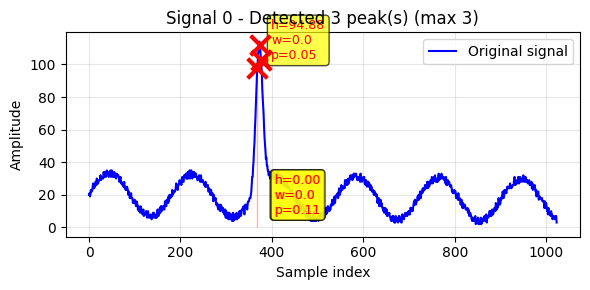

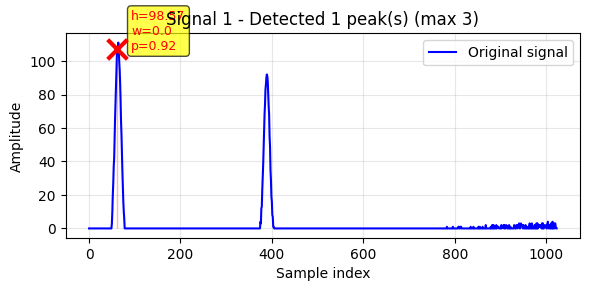

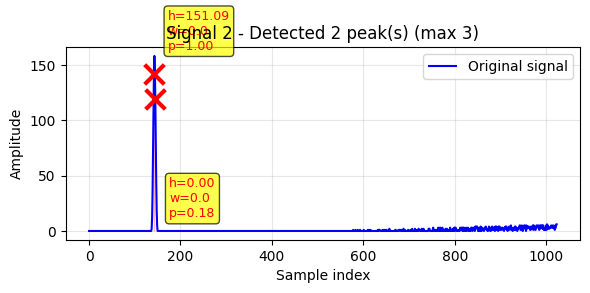

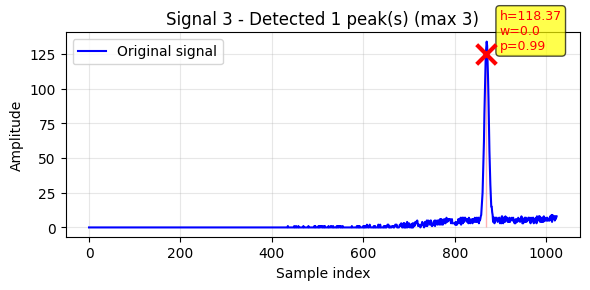

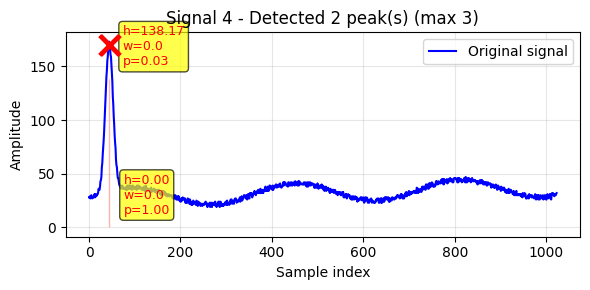

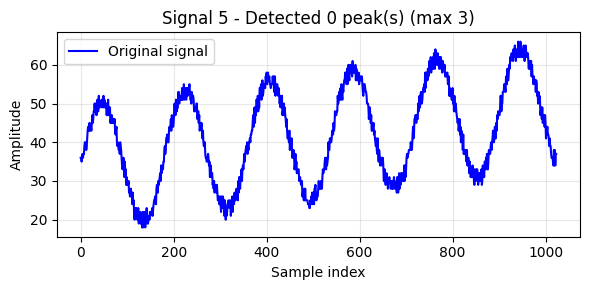

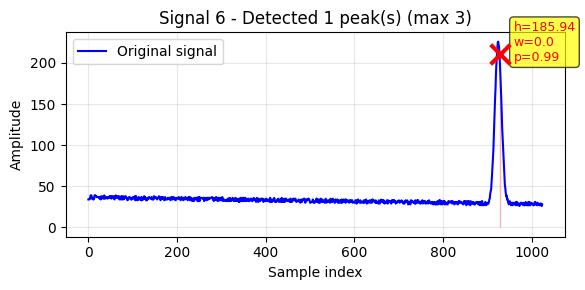

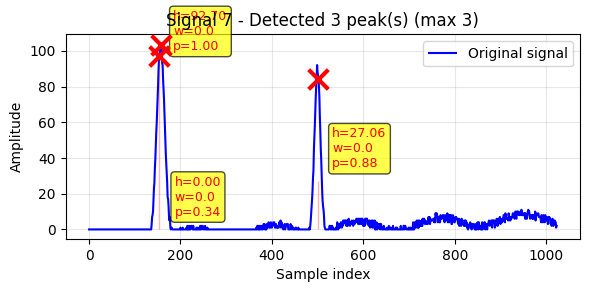

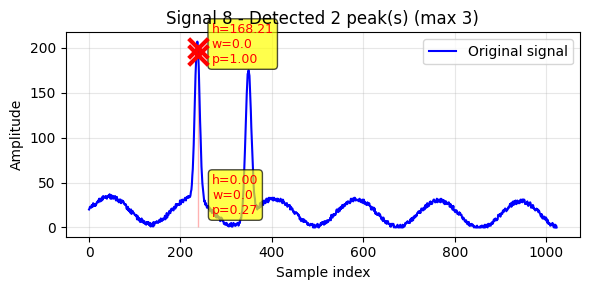

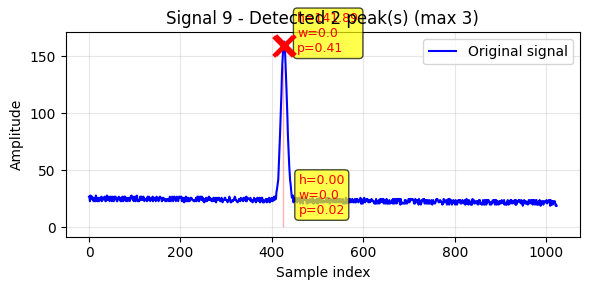

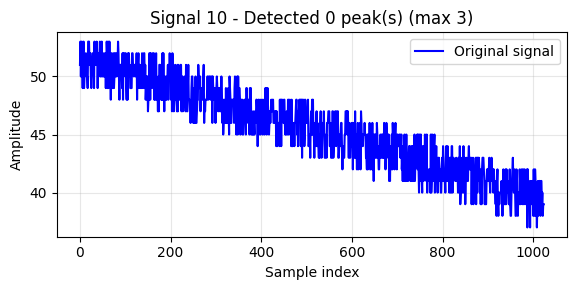

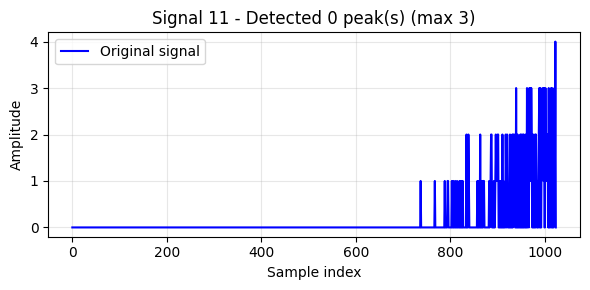

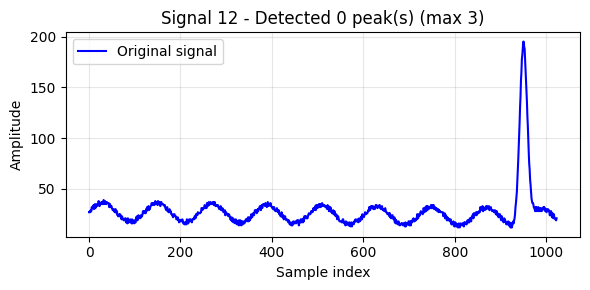

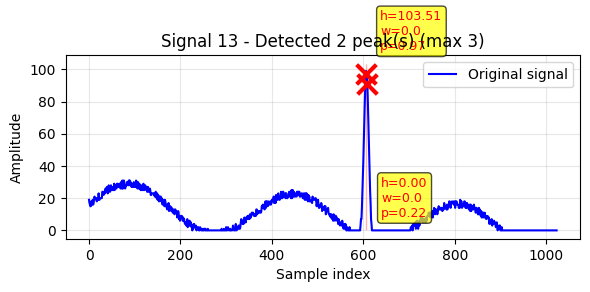

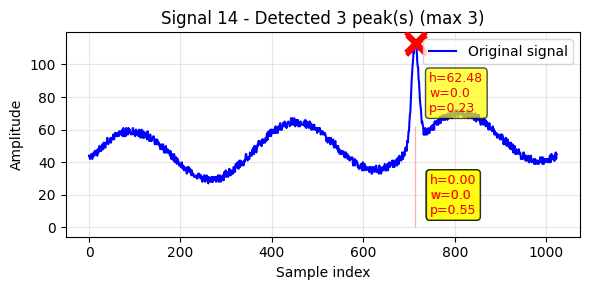

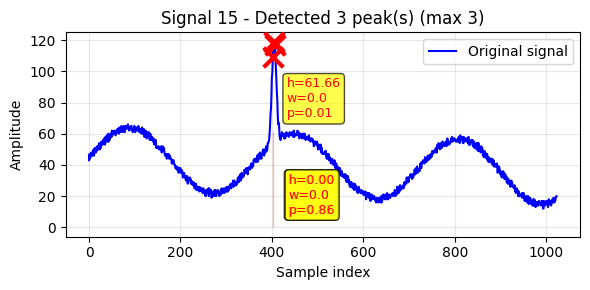

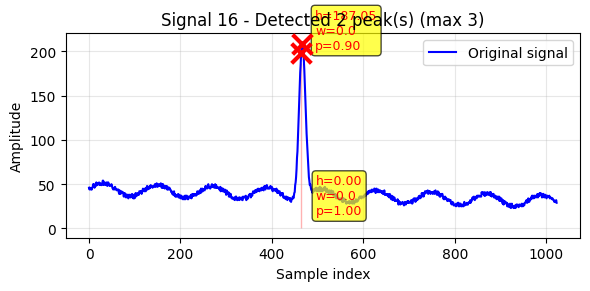

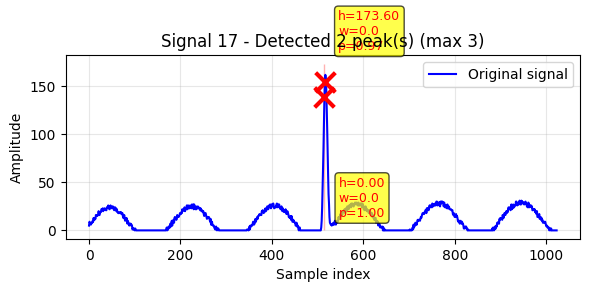

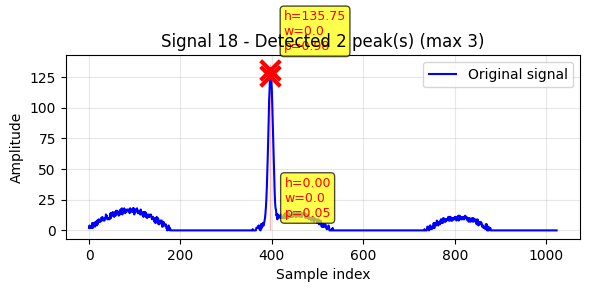

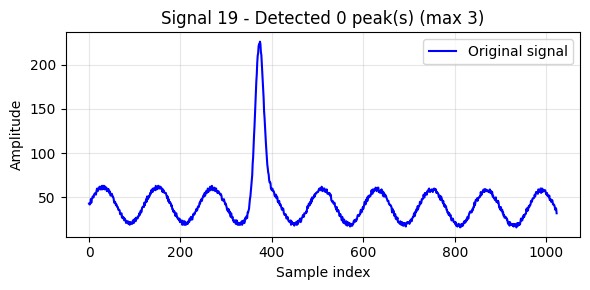

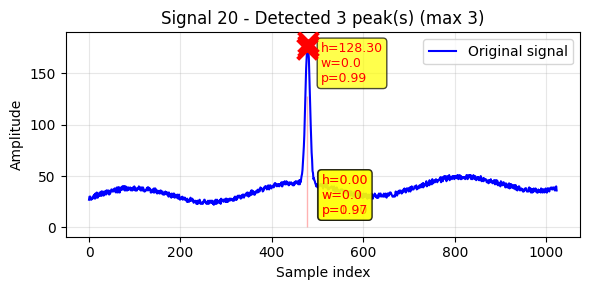

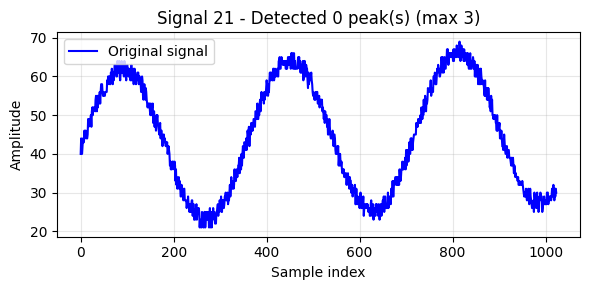

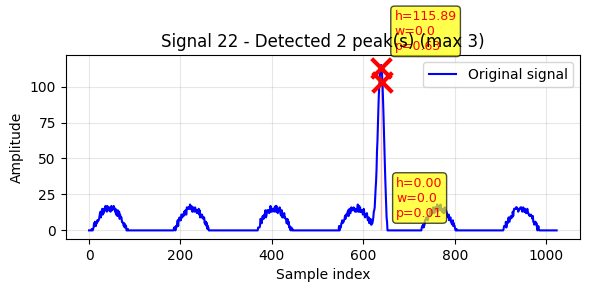

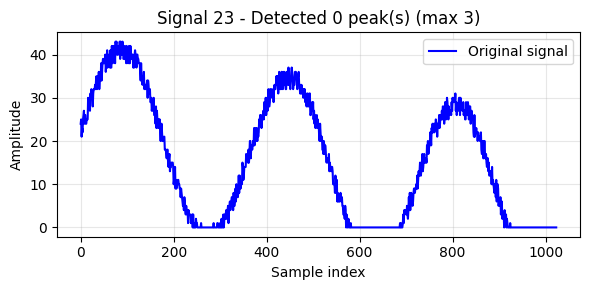

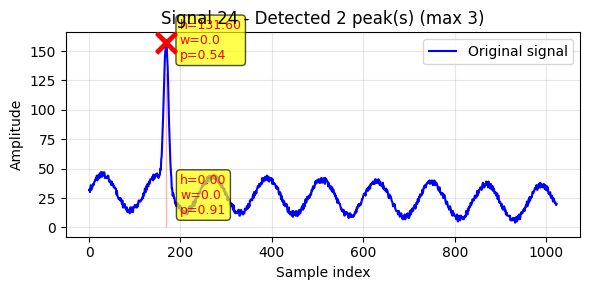

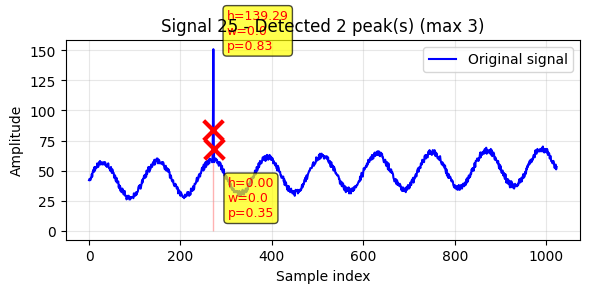

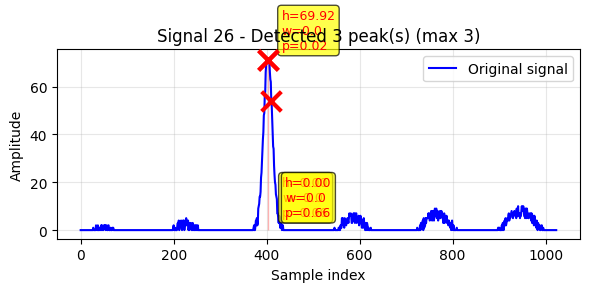

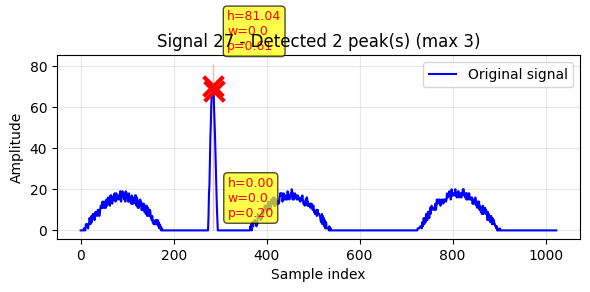

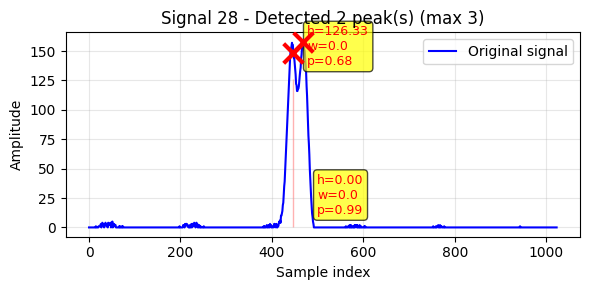

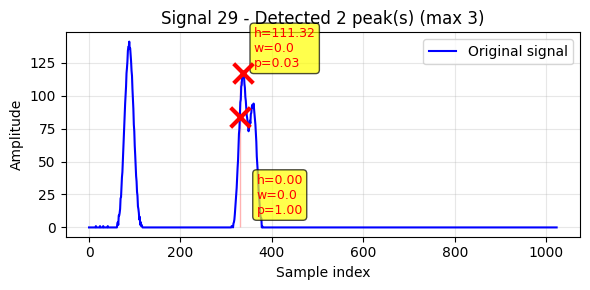

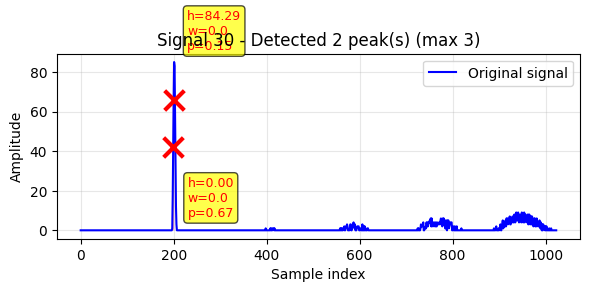

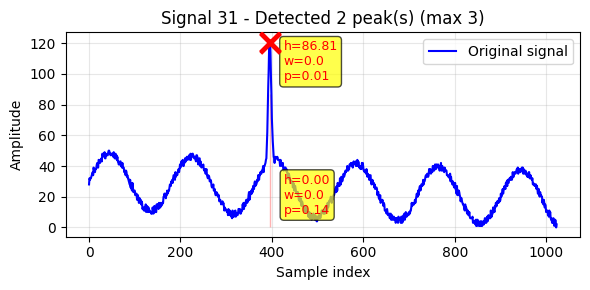

In [33]:
# -------------------- VISUALIZATION: TOP 3 PEAKS --------------------
for i in range(signals.shape[0]): 
    signal_example = signals[i].cpu().numpy()
    positions_pred = pred_pos[i]    
    heights_pred = pred_heights[i]
    widths_pred = pred_widths[i]
    
    plt.figure(figsize=(6, 3))
    plt.plot(signal_example, label="Original signal", linewidth=1.5, color='blue')
    
    peak_indices = np.where(positions_pred > threshold)[0]
    peak_probs = positions_pred[peak_indices]
    
    # Keep only top-3 peaks with highest probability
    if len(peak_indices) > 3:
        top_3_idx = np.argsort(peak_probs)[-3:]
        peak_indices = peak_indices[top_3_idx]
        peak_probs = peak_probs[top_3_idx]

    sort_idx = np.argsort(peak_indices)
    peak_indices = peak_indices[sort_idx]
    peak_probs = peak_probs[sort_idx]
    
    num_peaks = len(peak_indices)
    if num_peaks > 0:
        for idx in range(num_peaks):
            pos = peak_indices[idx]
            height = heights_pred[idx]
            width = widths_pred[idx]
            
            start = pos - width / 2
            stop = pos + width / 2
            
            # Colored rect
            plt.fill_between([start, stop], 0, height, 
                           alpha=0.3, color='red')
            
            # Horizontal line for heigh
            plt.hlines(height, start, stop, colors='red', linewidth=2)
            
            # Marker on the peack
            plt.scatter([pos], [signal_example[int(pos)]], 
                       s=200, color='red', marker='x', linewidths=3, zorder=5)
            
            # Note
            plt.annotate(f'h={height:.2f}\nw={width:.1f}\np={peak_probs[idx]:.2f}', 
                        xy=(pos, height),
                        xytext=(10, 10), textcoords='offset points',
                        fontsize=9, color='red',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    plt.title(f"Signal {i} - Detected {num_peaks} peak(s) (max 3)")
    plt.xlabel("Sample index")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

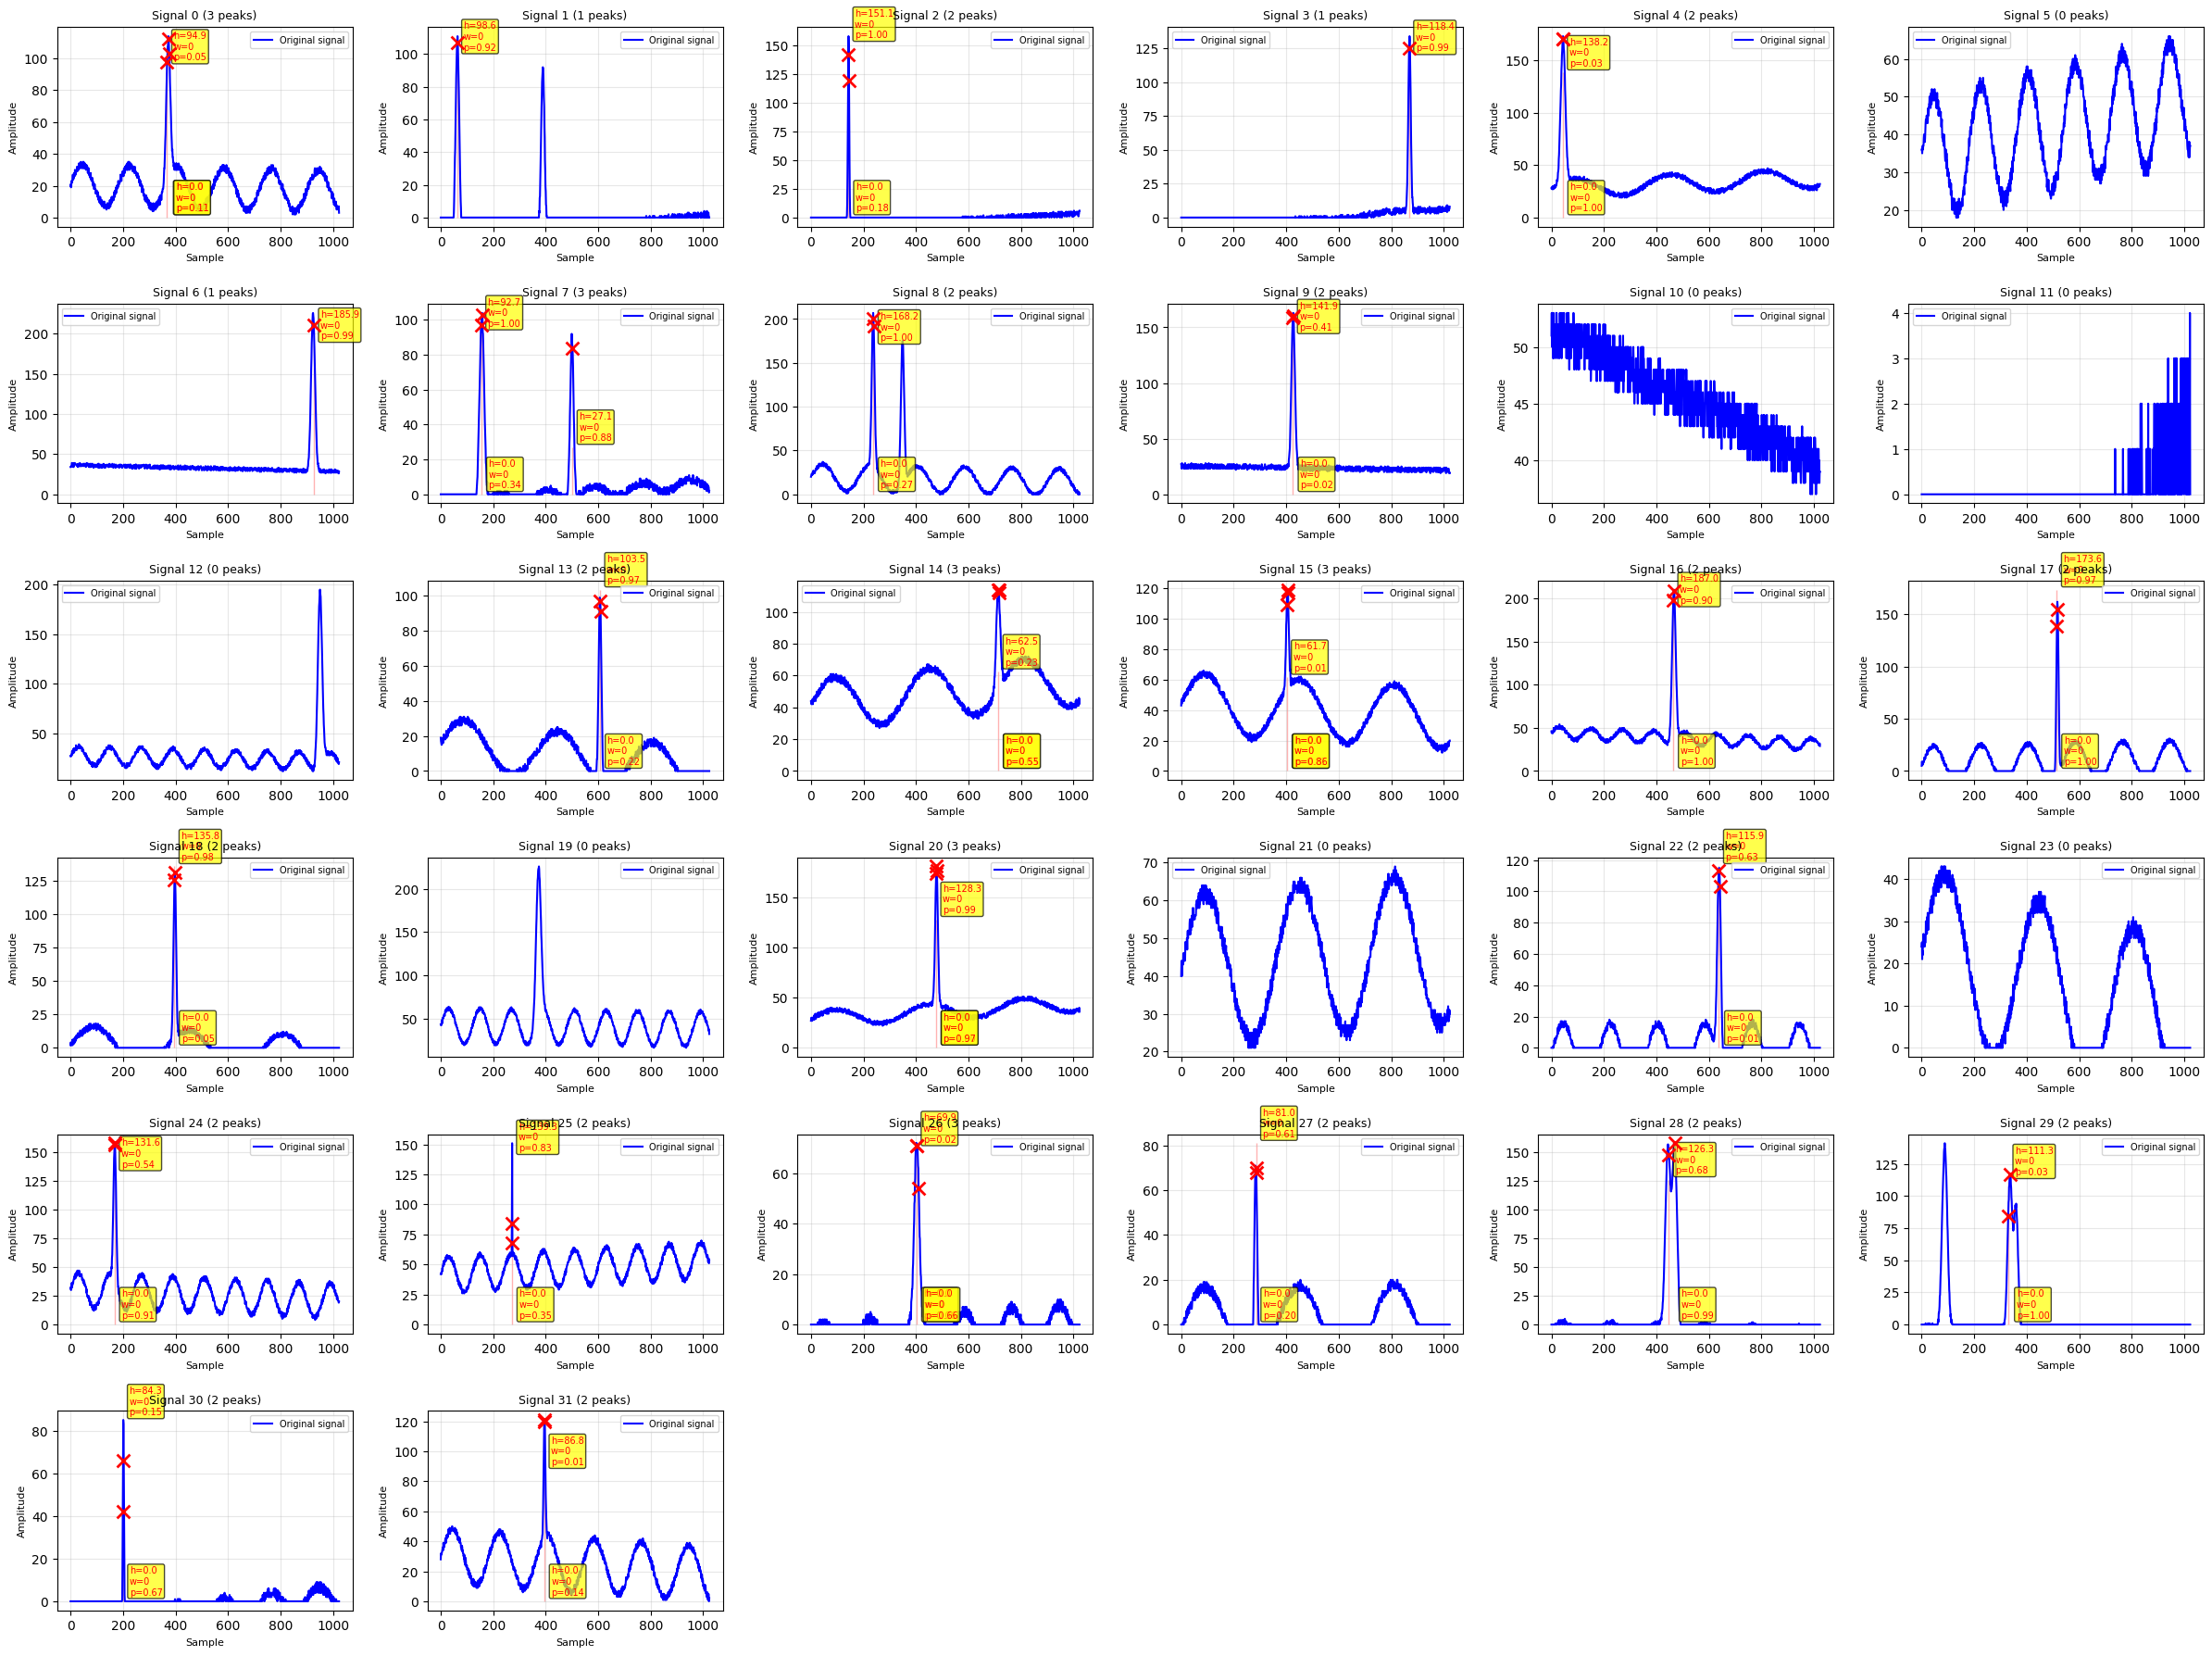

In [34]:
# -------------------- VISUALIZATION: TOP 3 PEAKS --------------------
num_signals = signals.shape[0]
cols = 6
rows = (num_signals + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
axes = axes.flatten() if num_signals > 1 else [axes]

for i in range(num_signals):
    ax = axes[i]
    signal_example = signals[i].cpu().numpy()
    positions_pred = pred_pos[i]    
    heights_pred = pred_heights[i]
    widths_pred = pred_widths[i]
    
    ax.plot(signal_example, label="Original signal", linewidth=1.5, color='blue')
    
    peak_indices = np.where(positions_pred > threshold)[0]
    peak_probs = positions_pred[peak_indices]
    
    if len(peak_indices) > 3:
        top_3_idx = np.argsort(peak_probs)[-3:]
        peak_indices = peak_indices[top_3_idx]
        peak_probs = peak_probs[top_3_idx]
    
    sort_idx = np.argsort(peak_indices)
    peak_indices = peak_indices[sort_idx]
    peak_probs = peak_probs[sort_idx]
    
    num_peaks = len(peak_indices)
    
    if num_peaks > 0:
        for idx in range(num_peaks):
            pos = peak_indices[idx]
            height = heights_pred[idx]
            width = widths_pred[idx]
            
            start = pos - width / 2
            stop = pos + width / 2
            
            ax.fill_between([start, stop], 0, height, alpha=0.3, color='red')
            ax.hlines(height, start, stop, colors='red', linewidth=2)
            ax.scatter([pos], [signal_example[int(pos)]], 
                       s=100, color='red', marker='x', linewidths=2, zorder=5)
            
            ax.annotate(f'h={height:.1f}\nw={width:.0f}\np={peak_probs[idx]:.2f}', 
                        xy=(pos, height),
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=7, color='red',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.7))
    
    ax.set_title(f"Signal {i} ({num_peaks} peaks)", fontsize=9)
    ax.set_xlabel("Sample", fontsize=8)
    ax.set_ylabel("Amplitude", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

for j in range(num_signals, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()